# Gene overlap across DE methods — the gene-level UpSet

Different differential-expression backends disagree at the margins. A natural
question is: **which genes are called by *several* methods, and what do those
robust genes do?** This notebook answers it with the gene-level UpSet trio:

`build_gene_membership` → `gene_upsetplot` → `common_genes` → `run_enrichment`

```{admonition} 📋 At a glance
:class: note

Dataset
: `EC.h5ad` (mouse spinal-cord endothelial cells, SCI vs. UN, 3 vs. 3), used
  through `adata.X` only.

You'll learn
: run the **same** SCI-vs-UN contrast through three DE backends (Wilcoxon,
  *t*-test, pseudobulk PyDESeq2) → stack them into a gene × set membership
  matrix → draw a gene-level UpSet (common-up and common-down as their own
  columns) → recolor it → pull the common genes out → enrich them.

Honest caveat
: this 3-vs-3 design has **no** genome-wide FDR-significant genes (`p_adj ≈ 1`),
  so we compare methods on an *exploratory* nominal-*p* signature. On a
  well-powered dataset you would feed the DE tables straight to
  `build_gene_membership` with a `padj_cutoff` (shown at the end).
```


In [1]:
%matplotlib inline

In [2]:
import sys
sys.path.insert(0, "../../src")  # use the in-repo scatrans, not any installed copy

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import scanpy as sc
import scatrans as scat

print("scatrans:", scat.__file__)

scatrans: /home/lieber/scATrans-main/docs/tutorials/../../src/scatrans/__init__.py


## 📥 Load the data

We only ever touch `adata.X` (raw counts). `store_raw_counts` preserves the full
measured gene set so enrichment later uses the correct background.

In [3]:
adata = sc.read_h5ad("../../EC.h5ad")
scat.store_raw_counts(adata)
adata.obs["condition"].value_counts()

condition
SCI    95
UN     82
Name: count, dtype: int64

## 🔬 Run the same contrast through three DE backends

Same `groupby`, same target/reference — only the statistical engine changes.

In [4]:
de = {}
de["wilcoxon"]   = scat.differential_expression(
    adata, groupby="condition", target_group="SCI", reference_group="UN",
    de_method="wilcoxon")[1]
de["ttest"]      = scat.differential_expression(
    adata, groupby="condition", target_group="SCI", reference_group="UN",
    de_method="t-test_overestim_var")[1]
de["pseudobulk"] = scat.differential_expression(
    adata, groupby="condition", target_group="SCI", reference_group="UN",
    use_pseudobulk=True, sample_col="sample")[1]

{k: v.shape for k, v in de.items()}

{'wilcoxon': (26451, 4), 'ttest': (26451, 4), 'pseudobulk': (26451, 4)}

## ⚠️ The honest caveat: FDR on a 3-vs-3 design

Before comparing methods, look at the adjusted p-values. With three replicates
per group and genome-wide multiple testing, **nothing survives FDR** — the
minimum `p_adj` is ~1.0. This is the whole reason `EC.h5ad` was chosen (see the
dataset provenance note in the tutorials index).

In [5]:
pd.DataFrame({
    "min_p_adj":       {k: float(v["p_adj"].min()) for k, v in de.items()},
    "n_padj_lt_0.05":  {k: int((v["p_adj"] < 0.05).sum()) for k, v in de.items()},
    "n_pval_lt_0.05":  {k: int((v["p_val"] < 0.05).sum()) for k, v in de.items()},
})

,min_p_adj,n_padj_lt_0.05,n_pval_lt_0.05
wilcoxon,1.000000,0,64
ttest,0.555478,0,729
pseudobulk,0.428695,0,53


So we drop to an **exploratory** view: nominal *p* < 0.05 and
|logFC| > 0.5, split by direction. (This is a hypothesis-generating signature,
not an FDR-controlled gene list — we say so out loud.)

In [6]:
def sig_genes(df, direction, p=0.05, lfc=0.5):
    mask = df["p_val"] < p
    mask &= (df["logFC"] > lfc) if direction == "up" else (df["logFC"] < -lfc)
    return df.index[mask].astype(str).tolist()

# Name each set with the ::up / ::down convention that common_genes understands.
gene_lists = {}
for name, df in de.items():
    gene_lists[f"{name}::up"]   = sig_genes(df, "up")
    gene_lists[f"{name}::down"] = sig_genes(df, "down")

{k: len(v) for k, v in gene_lists.items()}

{'wilcoxon::up': 56,
 'wilcoxon::down': 6,
 'ttest::up': 573,
 'ttest::down': 156,
 'pseudobulk::up': 14,
 'pseudobulk::down': 39}

## 🧱 Assemble the membership matrix

`build_gene_membership` also accepts ready-made gene lists (no thresholds
applied — each list becomes one set under its name). The result is a gene × set
0/1 matrix; the per-set gene lists are kept in `.attrs["gene_sets"]`.

In [7]:
mem = scat.pl.build_gene_membership(gene_lists)
print("membership:", mem.shape)
print("sets:", list(mem.columns))
mem.head()

membership: (739, 6)
sets: ['wilcoxon::up', 'wilcoxon::down', 'ttest::up', 'ttest::down', 'pseudobulk::up', 'pseudobulk::down']


,wilcoxon::up,wilcoxon::down,ttest::up,ttest::down,pseudobulk::up,pseudobulk::down
1110038F14Rik,0,0,1,0,0,0
1300002E11Rik,0,0,1,0,0,0
2610037D02Rik,0,0,1,0,0,0
2900026A02Rik,0,0,1,0,0,0
4930558N01Rik,0,0,1,0,0,0


## 📊 Draw the gene-level UpSet

Because we kept `::up` / `::down` as separate sets, the **common-up** column
(all three `*::up` dots filled) and the **common-down** column sit right in the
same figure.

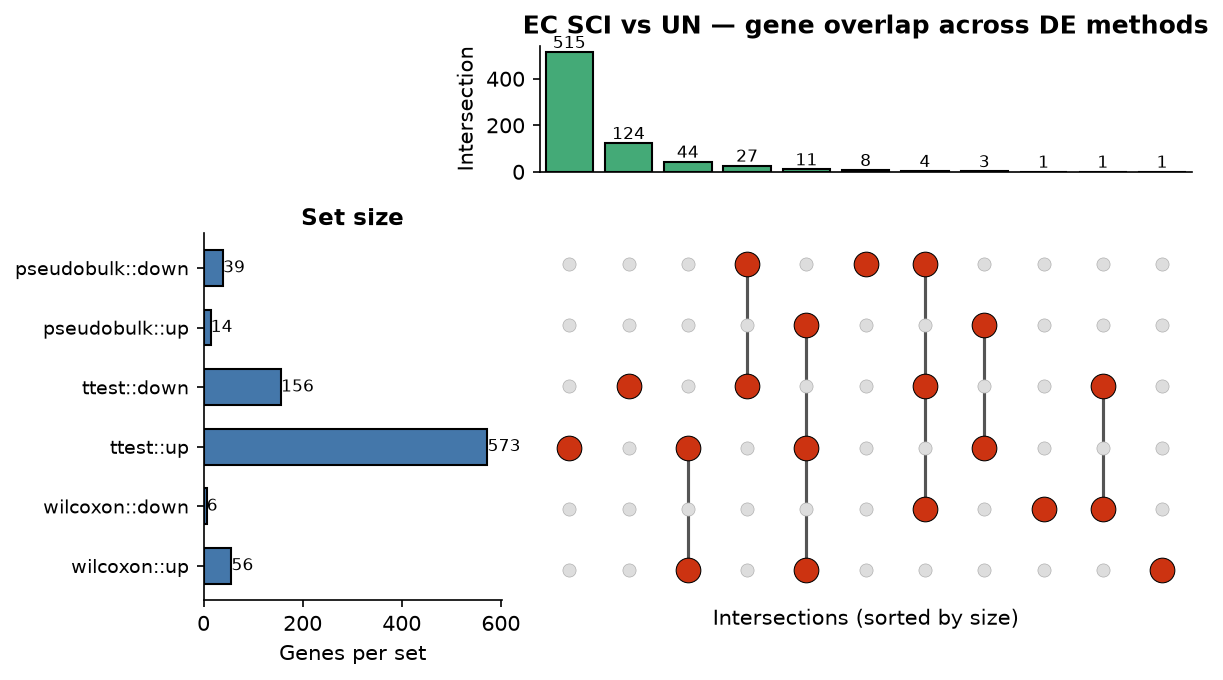

In [8]:
fig, ax = scat.pl.gene_upsetplot(
    membership=mem,
    title="EC SCI vs UN — gene overlap across DE methods",
    min_subset_size=1,
)

### 🎨 Every element is recolorable

Pass any matplotlib color to `set_color`, `intersection_color`, `dot_color`,
`inactive_color`, `line_color`. `intersection_color` and `dot_color` also accept
a **per-column list**, so you can highlight specific intersections.

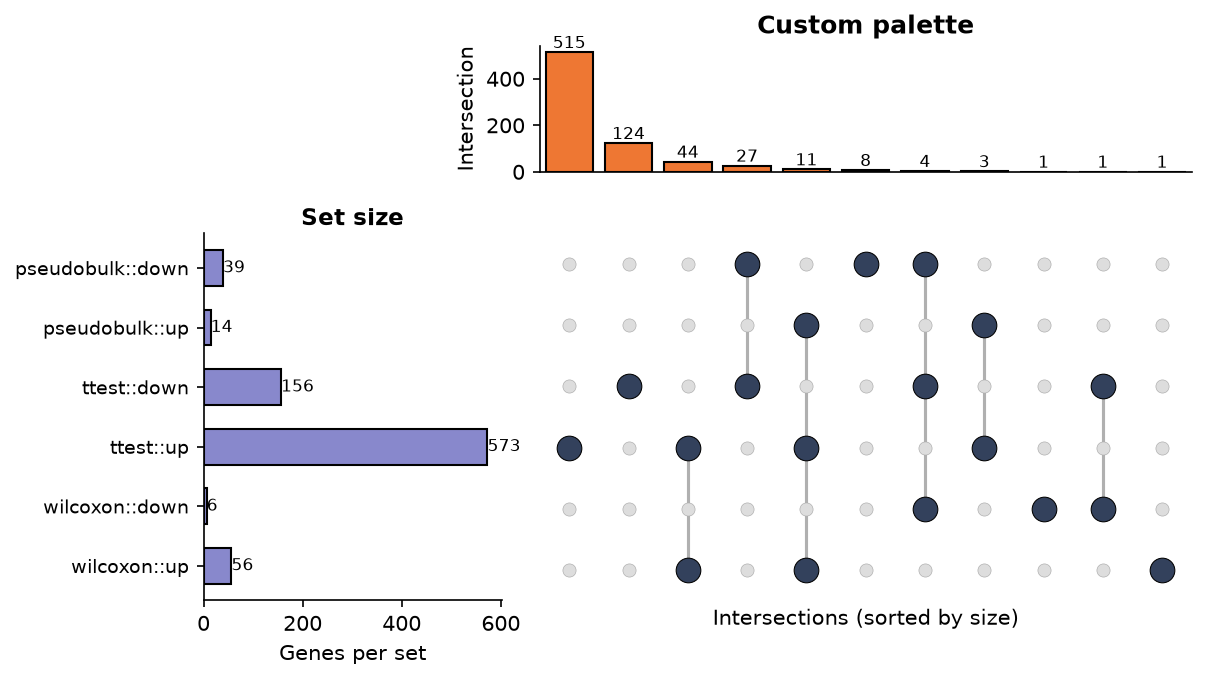

In [9]:
fig, ax = scat.pl.gene_upsetplot(
    membership=mem,
    title="Custom palette",
    set_color="#8888CC",
    intersection_color="#EE7733",
    dot_color="#33415C",
    line_color="#B0B0B0",
)

## 🧬 Pull the common genes back out

`common_genes` turns the intersection into a plain list — ready for enrichment.
`direction="up"` intersects every `*::up` set; `min_sets=` relaxes "all" to
"at least *k*".

In [10]:
common_up   = scat.pl.common_genes(mem, direction="up")     # up in ALL 3 methods
common_down = scat.pl.common_genes(mem, direction="down")   # down in ALL 3 methods
robust_up   = scat.pl.common_genes(mem, direction="up", min_sets=2)  # >= 2 of 3

print("common up (3/3):  ", len(common_up),  common_up)
print("common down (3/3):", len(common_down), common_down)
print("robust up (>=2/3):", len(robust_up))

common up (3/3):   11 ['Gfap', 'Gm68844', 'Net1', 'Pdxk', 'Rbms1', 'Rpl35', 'Rpl37', 'Rpl37a', 'Rpl38', 'Rps29', 'Spock2']
common down (3/3): 4 ['B2m', 'Cd81', 'Serpinh1', 'Ubb']
robust up (>=2/3): 58


## 🧭 Enrich the common-up and common-down genes separately

Up and down go into `run_enrichment` as two independent queries. Passing
`adata=` uses the preserved full gene set as the background.

In [11]:
enr_up = scat.run_enrichment(
    common_up, gene_sets="GO_Biological_Process", adata=adata, organism="mouse")
enr_up[["Term", "Count", "p.adjust"]].head(8)

,Term,Count,p.adjust
0,translation at postsynapse (GO:0140242),4,0.000033
1,translation at presynapse (GO:0140236),4,0.000033
2,translation at synapse (GO:0140241),4,0.000033
3,negative regulation of syncytium formation by ...,4,0.000033
4,negative regulation of myoblast fusion (GO:190...,4,0.000033
5,regulation of myoblast fusion (GO:1901739),4,0.000059
6,regulation of syncytium formation by plasma me...,4,0.000089
7,myoblast fusion (GO:0007520),4,0.000135


In [12]:
enr_down = scat.run_enrichment(
    common_down, gene_sets="GO_Biological_Process", adata=adata, organism="mouse")
enr_down[["Term", "Count", "p.adjust"]].head(8)

,Term,Count,p.adjust
0,T cell cytokine production (GO:0002369),2,0.035187
1,regulation of T cell cytokine production (GO:0...,2,0.035187
2,positive regulation of T cell cytokine product...,2,0.035187


## 🚀 On a well-powered dataset: skip the manual filtering

When genes *do* survive FDR, feed the DE tables straight to
`build_gene_membership` and let it filter for you — `direction="separate"` still
produces the `::up` / `::down` sets:

```python
mem = scat.pl.build_gene_membership(
    {"wilcoxon": de["wilcoxon"], "ttest": de["ttest"], "pseudobulk": de["pseudobulk"]},
    direction="separate",
    padj_cutoff=0.05, logfc_cutoff=0.5,
)
scat.pl.gene_upsetplot(membership=mem)
```

```{admonition} See also
:class: seealso

- {doc}`t_ec_standalone_de_enrichment` — the full DE + enrichment toolkit.
- {doc}`t_synthetic_visualization` — the complete `scat.pl` plotting gallery.
```
